# Importing Library

In [3]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [2]:
import os
import re
import requests
from PIL import Image
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score
import warnings
import pickle
warnings.filterwarnings('ignore')

# Loading the dataset

# Loading the train dataset

In [ ]:
train_data_dir = '/content/drive/MyDrive/chest_xray/train'
filepaths = []
labels = []

folds = os.listdir(train_data_dir)

for fold in folds:
    foldpath = os.path.join(train_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')

train_df = pd.concat([Fseries, Lseries], axis= 1)

In [1]:
train_df

NameError: name 'train_df' is not defined

# Loading the testing dataset

In [ ]:
test_data_dir = '/content/drive/MyDrive/chest_xray/test'
filepaths = []
labels = []

folds = os.listdir(test_data_dir)
for fold in folds:
    foldpath = os.path.join(test_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
test_df = pd.concat([Fseries, Lseries], axis= 1)

# Loading the validation dataset

In [ ]:
val_data_dir = '/content/drive/MyDrive/chest_xray/val'
filepaths = []
labels = []
folds = os.listdir(val_data_dir)
for fold in folds:
    foldpath = os.path.join(val_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
valid_df = pd.concat([Fseries, Lseries], axis= 1)

# Preprocessing

In [ ]:
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()
val_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = val_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 5221 validated image filenames belonging to 2 classes.
Found 16 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


# Showing the all images

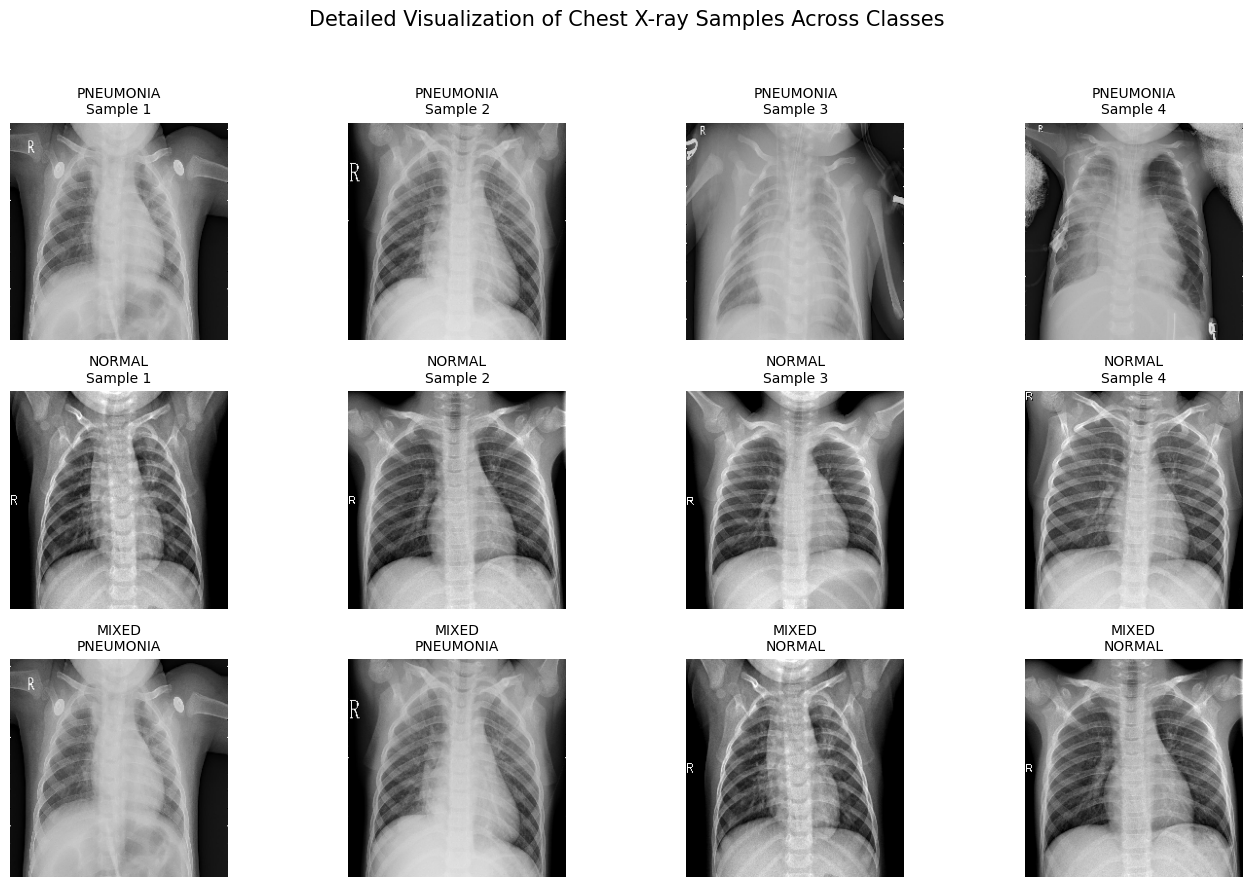

In [ ]:
g_dict = train_gen.class_indices
classes = list(g_dict.keys())

images, labels = next(train_gen)
label_indices = np.argmax(labels, axis=1)

pneumonia_idx = np.where(label_indices == classes.index('PNEUMONIA'))[0]
normal_idx = np.where(label_indices == classes.index('NORMAL'))[0]

n_samples = min(len(pneumonia_idx), len(normal_idx), 4)

pneumonia_samples = pneumonia_idx[:n_samples]
normal_samples = normal_idx[:n_samples]

mixed_samples = np.concatenate([
    pneumonia_samples[:n_samples//2],
    normal_samples[:n_samples - n_samples//2]
])

plt.figure(figsize=(14, 9))

for i, idx in enumerate(pneumonia_samples):
    plt.subplot(3, n_samples, i + 1)
    plt.imshow(images[idx] / 255)
    plt.title(f'PNEUMONIA\nSample {i+1}', fontsize=10)
    plt.axis('off')

for i, idx in enumerate(normal_samples):
    plt.subplot(3, n_samples, i + 1 + n_samples)
    plt.imshow(images[idx] / 255)
    plt.title(f'NORMAL\nSample {i+1}', fontsize=10)
    plt.axis('off')

for i, idx in enumerate(mixed_samples):
    plt.subplot(3, n_samples, i + 1 + 2*n_samples)
    class_name = classes[label_indices[idx]]
    plt.imshow(images[idx] / 255)
    plt.title(f'MIXED\n{class_name}', fontsize=10)
    plt.axis('off')

plt.suptitle(
    'Detailed Visualization of Chest X-ray Samples Across Classes',
    fontsize=15
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Pixel Intensity Distribution of Chest X-ray Images

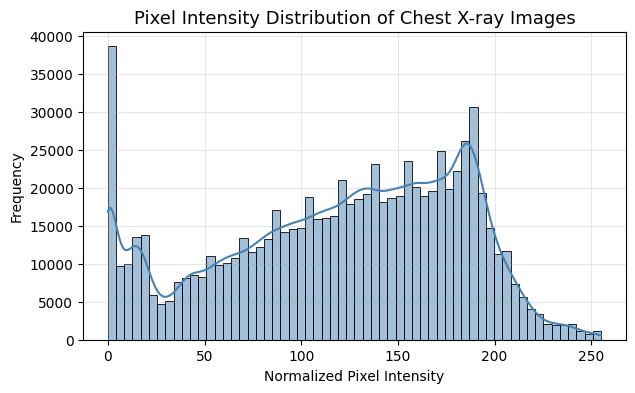

In [ ]:
sample_images, _ = next(train_gen)
gray_pixels = []

for img in sample_images:
    gray = np.mean(img, axis=2)
    gray_pixels.extend(gray.flatten())

plt.figure(figsize=(7,4))
sns.histplot(
    gray_pixels,
    bins=60,
    kde=True,
    color='steelblue'
)

plt.title('Pixel Intensity Distribution of Chest X-ray Images', fontsize=13)
plt.xlabel('Normalized Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()


# Model Implemention

# Implement 1st model

In [ ]:
# CNN Model Architecture
model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')  # NORMAL vs PNEUMONIA
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,026 (98.36 MB)

 Trainable params: 25,784,578 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

# Compile the model

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Define callbacks

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
    ModelCheckpoint(
        'best_cnn_model.h5',
        monitor='val_accuracy',
        save_best_only=True
    )
]

# Train the model

In [ ]:
epochs = 5

history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=callbacks
)

Epoch 1/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8894 - loss: 0.7409

327/327 ━━━━━━━━━━━━━━━━━━━━ 2591s 8s/step - accuracy: 0.9312 - loss: 0.3016 - val_accuracy: 0.8125 - val_loss: 0.3121 - learning_rate: 1.0000e-04
Epoch 2/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9663 - loss: 0.0940

327/327 ━━━━━━━━━━━━━━━━━━━━ 1132s 3s/step - accuracy: 0.9703 - loss: 0.0812 - val_accuracy: 1.0000 - val_loss: 0.0167 - learning_rate: 1.0000e-04
Epoch 3/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 1148s 3s/step - accuracy: 0.9810 - loss: 0.0517 - val_accuracy: 0.6250 - val_loss: 2.0388 - learning_rate: 1.0000e-04
Epoch 4/5
 90/327 ━━━━━━━━━━━━━━━━━━━━ 13:17 3s/step - accuracy: 0.9772 - loss: 0.0624

# Plot training and validation curves

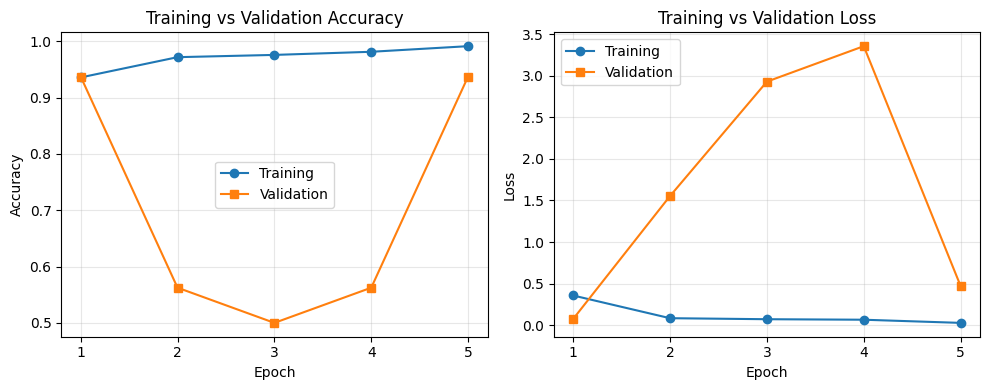

In [ ]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, history.history['accuracy'], marker='o')
plt.plot(epochs, history.history['val_accuracy'], marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend(['Training', 'Validation'])

plt.subplot(1,2,2)
plt.plot(epochs, history.history['loss'], marker='o')
plt.plot(epochs, history.history['val_loss'], marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend(['Training', 'Validation'])

plt.tight_layout()
plt.show()


# Evaluate model on TEST data

In [ ]:
test_gen.reset()
predictions = model.predict(test_gen)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes


# Confusion Matrix

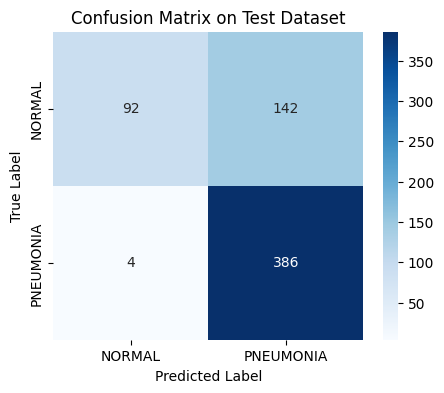

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Dataset')
plt.show()

# Classification Report

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

# Implementing 2nd Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

In [ ]:
epochs = 4

history_mobilenet = mobilenet_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/4
327/327 ━━━━━━━━━━━━━━━━━━━━ 151s 450ms/step - accuracy: 0.8441 - loss: 0.3528 - val_accuracy: 0.6875 - val_loss: 1.0752 - learning_rate: 1.0000e-04
Epoch 2/4
327/327 ━━━━━━━━━━━━━━━━━━━━ 153s 468ms/step - accuracy: 0.9081 - loss: 0.2196 - val_accuracy: 0.6875 - val_loss: 1.3009 - learning_rate: 1.0000e-04
Epoch 3/4
327/327 ━━━━━━━━━━━━━━━━━━━━ 148s 452ms/step - accuracy: 0.9219 - loss: 0.1889 - val_accuracy: 0.6875 - val_loss: 1.2816 - learning_rate: 1.0000e-04
Epoch 4/4
327/327 ━━━━━━━━━━━━━━━━━━━━ 203s 456ms/step - accuracy: 0.9307 - loss: 0.1725 - val_accuracy: 0.6875 - val_loss: 1.2826 - learning_rate: 3.0000e-05


In [ ]:
epochs = range(1, len(history_mobilenet.history['accuracy']) + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, history_mobilenet.history['accuracy'])
plt.plot(epochs, history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])

plt.subplot(1,2,2)
plt.plot(epochs, history_mobilenet.history['loss'])
plt.plot(epochs, history_mobilenet.history['val_loss'])
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])

plt.tight_layout()
plt.show()

In [ ]:
test_gen.reset()

predictions = mobilenet_model.predict(test_gen)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

      NORMAL       0.81      0.38      0.52       234
   PNEUMONIA       0.72      0.95      0.82       390

    accuracy                           0.73       624
   macro avg       0.76      0.66      0.67       624
weighted avg       0.75      0.73      0.70       624



# Showing Comparison Plot

In [ ]:
# CNN Accuracy
test_gen.reset()
cnn_predictions = model.predict(test_gen)
cnn_pred = np.argmax(cnn_predictions, axis=1)
cnn_true = test_gen.classes

cnn_accuracy = accuracy_score(cnn_true, cnn_pred)

# MobileNetV2 Accuracy
test_gen.reset()
mobile_predictions = mobilenet_model.predict(test_gen)
mobile_pred = np.argmax(mobile_predictions, axis=1)
mobile_true = test_gen.classes

mobile_accuracy = accuracy_score(mobile_true, mobile_pred)

# Model names and accuracy values
models = ['CNN', 'MobileNetV2']
accuracies = [cnn_accuracy, mobile_accuracy]

# Define different colors
colors = ['royalblue', 'seagreen']

plt.figure(figsize=(6,4))

bars = plt.bar(models, accuracies, color=colors)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')

# Adding data labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Saving the best model

In [ ]:
if cnn_accuracy > mobile_accuracy:
    best_model = model
    best_model_name = "CNN"
    best_accuracy = cnn_accuracy
else:
    best_model = mobilenet_model
    best_model_name = "MobileNetV2"
    best_accuracy = mobile_accuracy

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

with open('best_pneumonia_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved as best_pneumonia_model.pkl")

Best Model: CNN
Best Accuracy: 0.7660256410256411
Best model saved as best_pneumonia_model.pkl
